# Exercice partie 3 - Analysez des données de systèmes éducatifs

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.ticker as ticker

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [8]:
data = pd.read_csv('data/processed/final_data.csv', sep=',')

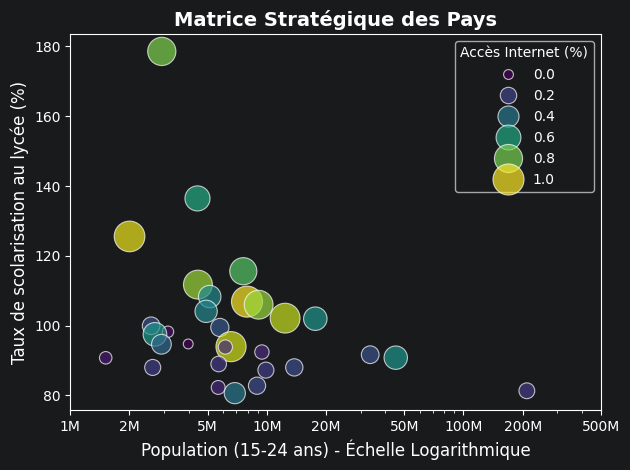

In [9]:
data['internet_visual_boost'] = data['internet_per_100'] ** 3

sns.scatterplot(data=data,
                x='age_15_24',
                y='enrolment_ratio_upper_secondary',
                size='internet_visual_boost',
                hue='internet_visual_boost',
                palette='viridis',
                sizes=(50, 500),
                alpha=0.7,
                color='teal')

# Echelle log pour éviter que le graphique soit écrasé a cause des outliner Inde et Chine sur l'indicateur age_15_24
plt.xscale('log')

ax = plt.gca()

# Gestion des grands chiffres
ax.set_xticks([1e6, 2e6, 5e6, 10e6, 20e6, 50e6, 100e6, 200e6, 500e6])
formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x * 1e-6)}M' if x >= 1e6 else f'{int(x)}')
ax.xaxis.set_major_formatter(formatter)

plt.title("Matrice Stratégique des Pays", fontsize=14, fontweight='bold')
plt.xlabel("Population (15-24 ans) - Échelle Logarithmique", fontsize=12)
plt.ylabel("Taux de scolarisation au lycée (%)", fontsize=12)
plt.legend(
    title="Accès Internet (%)",
)

plt.tight_layout()
plt.show()

In [10]:
scaler = MinMaxScaler()

# On recalcule la moyenne pondérée avec ce nouvel indicateur
data['internet_per_100_score'] = scaler.fit_transform(data[['internet_per_100']])
data['global_score'] = (data['population_score'] + data['enrolment_ratio_score'] + data['internet_per_100_score']) / 3

# Tri par score global décroissant
top_pays_finaux = data.sort_values('global_score', ascending=False)

print(f'Nombre de pays sélectionnés : {len(top_pays_finaux)}')

Nombre de pays sélectionnés : 31


Voici ma recommandation finale des pays ou aller essayer de s'implanter :


In [11]:
top_pays_finaux = top_pays_finaux[top_pays_finaux['Country Name'] != 'France']

top_pays_finaux = top_pays_finaux[['Country Name', 'age_15_24', 'enrolment_ratio_upper_secondary', 'internet_per_100', 'population_score', 'enrolment_ratio_score', 'internet_per_100_score', 'global_score']]

top_pays_finaux_cleaned = top_pays_finaux.rename(columns={
    'Country Name': 'Pays',
    'enrolment_ratio_upper_secondary': 'Pourcentage scolarisation',
    'internet_per_100': 'Internet pour 100 habitants',
    'age_15_24' : 'Nombre d\'habitants 15/24 ans',
    'global_score': 'Score',
})

top_pays_finaux_cleaned.drop(['population_score', 'enrolment_ratio_score', 'internet_per_100_score'], axis=1, inplace=True)

In [12]:
top_pays_finaux_cleaned.reset_index(drop=True, inplace=True)
top_pays_finaux_cleaned.head(10)

,Pays,Nombre d'habitants 15/24 ans,Pourcentage scolarisation,Internet pour 100 habitants,Score
0,Australia,2920804.4,178.556668,0.931025,0.645923
1,China,210099514.8,81.335791,0.561325,0.522744
2,Netherlands,2002184.0,125.555078,0.991354,0.484097
3,Spain,4436945.4,136.442825,0.850020,0.477949
4,United Kingdom,7923198.0,106.872313,1.000000,0.432828
5,Canada,4459604.4,111.744696,0.947921,0.426523
6,Japan,12379060.0,102.142018,0.970712,0.414079
7,Germany,9080370.2,105.991877,0.945886,0.413641
8,"Korea, Rep.",6571138.4,93.980776,0.978272,0.379530
9,United States,45246251.8,90.821086,0.803757,0.372405
